### This notebook reproduces all plots from the main paper and supplementary information, saving them to the plots directory.

In [93]:
import math
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [95]:
plot_dir = Path("figures")
Path(plot_dir).mkdir(exist_ok=True)

### Main experiment

In [96]:
def save_main_exp_plot(plot_dir: Path):
    datasets = [
        {
            "title": r"E2/S$_N$2",
            "unit": "kcal/mol", 
            "values": {
                "Chemprop-CGR": {"acc": 2.64, "acc_std": 0.10},
                "Chemprop-diff": {"acc": 2.76, "acc_std": 0.08},
                "RXNFP": {"acc": 3.37, "acc_std": 0.10},
                "SMILES": {"acc": 3.03, "acc_std": 0.16},
                "SMILES/CGR": {"acc": 3.42, "acc_std": 0.12},
                "sr-SMILES": {"acc": 2.40, "acc_std": 0.07},
            },
        },
        {
            "title": "Phosphatase",
            "unit": "% yield", 
            "values": {
                "Chemprop-CGR": {"acc": 0.062, "acc_std": 0.005},
                "Chemprop-diff": {"acc": 0.066, "acc_std": 0.007},
                "RXNFP": {"acc": 0.066, "acc_std": 0.007},
                "SMILES": {"acc": 0.068, "acc_std": 0.004},
                "SMILES/CGR": {"acc": 0.069, "acc_std": 0.004},
                "sr-SMILES": {"acc": 0.069, "acc_std": 0.006},
            },
        },
        {
            "title": "Lograte",
            "unit": "unitless", 
            "values": {
                "Chemprop-CGR": {"acc": 0.41, "acc_std": 0.02},
                "Chemprop-diff": {"acc": 0.45, "acc_std": 0.007},
                "RXNFP": {"acc": 0.90, "acc_std": 0.11},
                "SMILES": {"acc": 0.55, "acc_std": 0.09},
                "SMILES/CGR": {"acc": 0.61, "acc_std": 0.13},
                "sr-SMILES": {"acc": 0.57, "acc_std": 0.13},
            },
        },
        {
            "title": "Rad-6-RE",
            "unit": "eV", 
            "values": {
                "Chemprop-CGR": {"acc": 0.13, "acc_std": 0.01},
                "Chemprop-diff": {"acc": 0.4, "acc_std": 0.00},
                "RXNFP": {"acc": 0.65, "acc_std": 0.01},
                "SMILES": {"acc": 0.40, "acc_std": 0.11},
                "SMILES/CGR": {"acc": 0.46, "acc_std": 0.09},
                "sr-SMILES": {"acc": 0.38, "acc_std": 0.07},
            },
        },
        {
            "title": r"S$_N$Ar",
            "unit": "kcal/mol", 
            "values": {
                "Chemprop-CGR": {"acc": 0.85, "acc_std": 0.12},
                "Chemprop-diff": {"acc": 0.94, "acc_std": 0.21},
                "RXNFP": {"acc": 0.98, "acc_std": 0.13},
                "SMILES": {"acc": 0.92, "acc_std": 0.12},
                "SMILES/CGR": {"acc": 1.08, "acc_std": 0.25},
                "sr-SMILES": {"acc": 0.97, "acc_std": 0.14},
            },
        },
        {
            "title": "GDB",
            "unit": "kcal/mol", 
            "values": {
                "Chemprop-CGR": {"acc": 4.25, "acc_std": 0.19},
                "Chemprop-diff": {"acc": 5.26, "acc_std": 0.15},
                "RXNFP": {"acc": 10.94, "acc_std": 0.29},
                "SMILES": {"acc": 10.95, "acc_std": 1.35},
                "SMILES/CGR": {"acc": 9.02, "acc_std": 0.28},
                "sr-SMILES": {"acc": 8.03, "acc_std": 0.18},
            },
        },
    ]
    
    plt.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "axes.linewidth": 0.8,
            "axes.spines.top": False,
            "axes.spines.right": False,
        }
    )

    fig, axes = plt.subplots(3, 2, figsize=(8.5, 12))
    axes = axes.flatten()

    for idx, exp in enumerate(datasets):
        
        ax = axes[idx]
        model2values = exp["values"]
        title = exp["title"]
        unit = exp["unit"]

        models = list(model2values.keys())
        acc_means = [model2values[m]["acc"] for m in models]
        acc_stds = [model2values[m]["acc_std"] for m in models]
        divider = math.sqrt(10) if title == "GDB" else math.sqrt(5)
        acc_stds = [error / divider for error in acc_stds]

        colors = [
            "#1f77b4",
            "#1f77b4",
            "#1f77b4",
            "#d62728",
            "#d62728",
            "#d62728",
        ]

        x = np.arange(len(models))
        bars = ax.bar(x, acc_means, yerr=acc_stds, capsize=4, color=colors)

        for spine in ax.spines.values():
            spine.set_visible(False)

        space = 0.03 * max(acc_means)
        for i, (val, err) in enumerate(zip(acc_means, acc_stds)):
            ax.text(
                i,
                val + err + space,
                f"{val}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

        ax.grid(True, axis="y", linestyle="--", alpha=0.7)
        ax.set_title(title, pad=15, fontsize=13)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=35, ha="right", fontsize=10)
        ax.set_ylabel(f"MAE ({unit})", fontsize=11)
        ax.set_ylim(0, max(acc_means) * 1.2)
            
    plt.tight_layout()
    save_path = plot_dir / "main_exp.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {save_path}")
    plt.show()
    plt.close(fig)

Saved plot to: figures/main_exp.png


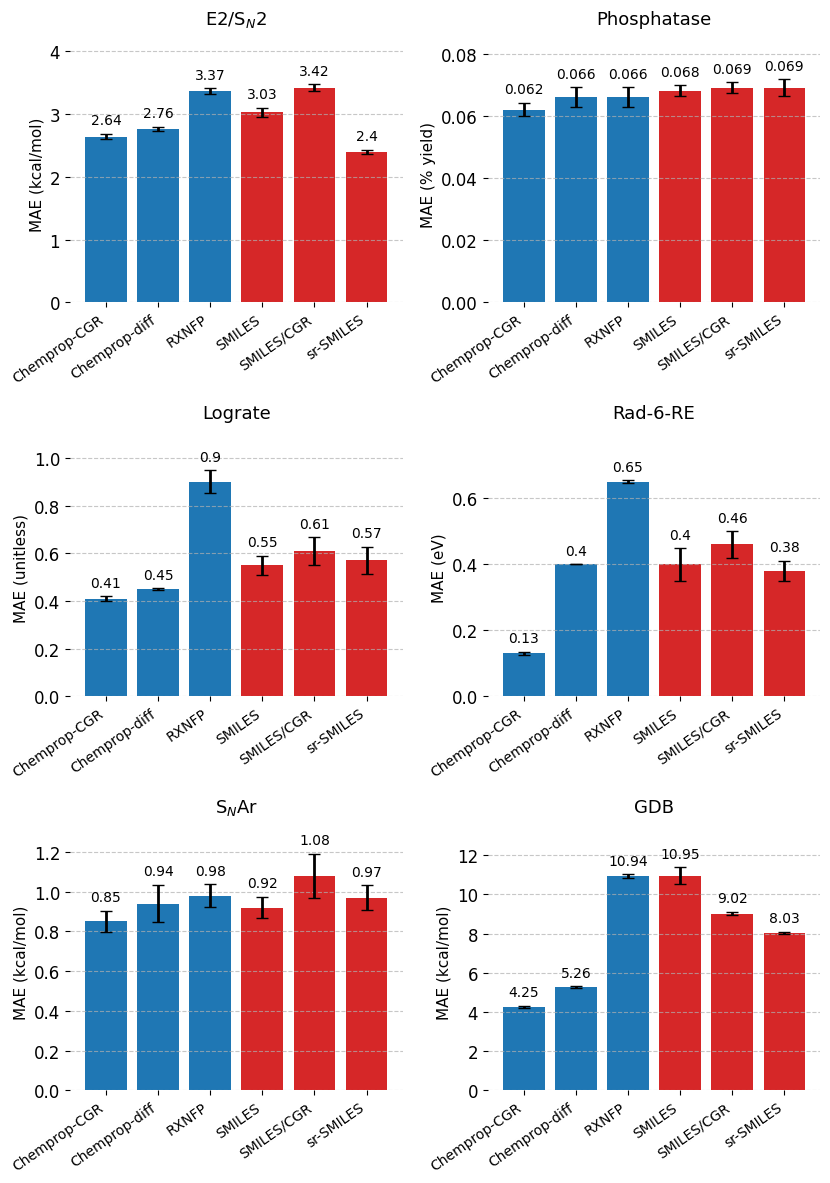

In [97]:
save_main_exp_plot(plot_dir)


### GDB remap experiment

In [98]:
def save_gdb_remap_experiment_plot(plot_dir: Path):

    model2values = {
        "Chemprop-CGR": {
            "acc": 4.25,
            "acc_std": 0.19
        },
        "Chemprop-diff": {
            "acc": 5.25,
            "acc_std": 0.15
        },
        "RXNFP": {
            "acc": 10.94,
            "acc_std": 0.29
        },
        # "SMILES\Original": {
        #     "acc": 14.18,
        #     "acc_std": 0.92
        # },
        "SMILES/CGR\nOriginal": {
            "acc": 9.017,
              "acc_std": 0.28
        },
        "SMILES/CGR\nRemapped": {
            "acc": 10.08,
              "acc_std": 0.26 
        },
        "sr-SMILES\nOriginal": {
            "acc": 8.03,
            "acc_std": 0.18
        },
        "sr-SMILES\nRemapped": {
            "acc": 9.39,
            "acc_std": 0.41
        },
    }
    models = list(model2values.keys())
    acc_means = [model2values[m]["acc"] for m in models]
    acc_stds = [model2values[m]["acc_std"] for m in models]
    acc_stds = [error / math.sqrt(10) for error in acc_stds]
    colors = ["#1f77b4"] * 3 + ["#d62728"] * 5

    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.linewidth": 0.8,
        "axes.spines.top": True,
        "axes.spines.right": True,
    })

    fig, ax = plt.subplots(figsize=(7, 5))
    x = np.arange(len(models))

    bars = ax.bar(
        x,
        acc_means,
        yerr=acc_stds,
        capsize=3,
        color=colors,
        linewidth=0,
    )
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        err = acc_stds[i]
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + err + 0.03,
            f"{acc_means[i]:.2f}",
            ha="center",
            va="bottom",
            fontsize=11,
            color="black",
        )

    ax.set_ylabel("MAE (kcal/mol)", fontsize=12)
    ax.set_title(r"GDB MAE (kcal/mol)", fontsize=14, pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(False)

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)
        
    ax.set_ylim(0, max(np.array(acc_means) + np.array(acc_stds)) *1.1)
    plt.tight_layout()

    save_path = plot_dir / "gdb_remap_2.png"
    fig.savefig(save_path, dpi=900, bbox_inches="tight")
    fig.show()


/var/folders/m8/8j0c5mbs20q5dx1pnzcq3xjh0000gn/T/ipykernel_60898/1006544701.py:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


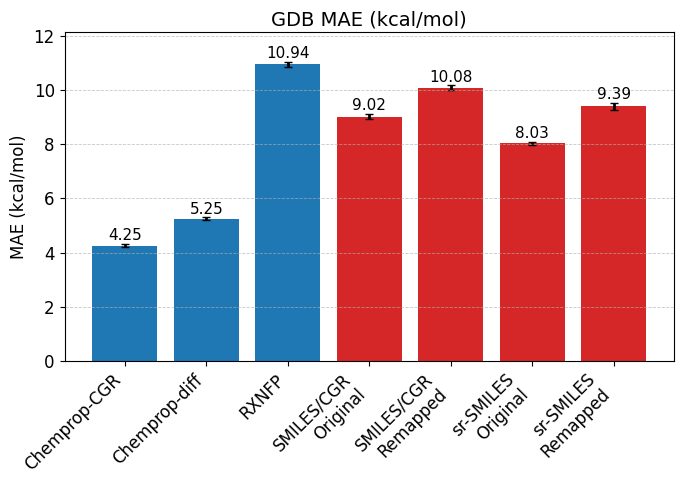

In [99]:
save_gdb_remap_experiment_plot(plot_dir)


### Learning curve experiment

In [100]:
def dataset_size_exp(plot_dir: Path):
    x = np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.0])
    
    data = {
        'Rad-6-RE': {
            'SMILES':    np.array([3.16, 2.95, 2.53, 0.43, 0.43, 0.40]),
            'SMILES/CGR':np.array([1.87, 1.61, 1.93, 0.62, 0.59, 0.46]),
            'sr-SMILES': np.array([1.91, 1.67, 1.39, 0.53, 0.51, 0.38]),
        },
        'E2/SN2': {
            'SMILES':    np.array([5.30, 3.80, 3.37, 3.21, 3.06, 3.03]),
            'SMILES/CGR':np.array([5.84, 4.24, 3.84, 3.55, 3.45, 3.42]),
            'sr-SMILES': np.array([4.66, 3.46, 2.86, 2.69, 2.42, 2.40]),
        },
        'SNAR': {
            'SMILES':    np.array([2.24, 1.50, 1.24, 1.03, 0.90, 0.92]),
            'SMILES/CGR':np.array([2.22, 1.67, 1.57, 1.35, 1.16, 1.08]),
            'sr-SMILES': np.array([2.23, 1.53, 1.36, 1.17, 0.98, 0.97]),
        },
        'Lograte': {
            'SMILES':    np.array([1.23, 0.83, 0.70, 0.60, 0.57, 0.55]),
            'SMILES/CGR':np.array([1.39, 0.94, 0.78, 0.68, 0.64, 0.61]),
            'sr-SMILES': np.array([1.19, 0.79, 0.66, 0.59, 0.59, 0.57]),
        },
        'Phosphatase': {
            'SMILES':    np.array([0.092, 0.079, 0.078, 0.074, 0.074, 0.068]),
            'SMILES/CGR':np.array([0.093, 0.082, 0.074, 0.076, 0.071, 0.069]),
            'sr-SMILES': np.array([0.092, 0.079, 0.077, 0.073, 0.072, 0.069]),
        },
        'GDB': {
            'SMILES':    np.array([15.97, 13.60, 12.29, 11.43, 11.03, 10.95]),
            'SMILES/CGR':np.array([14.39, 11.76, 11.14, 10.40,  9.96,  9.02]),
            'sr-SMILES': np.array([13.90, 10.89,  9.73,  9.15,  8.66,  8.03]),
        },
    }
    
    data_std = {
        'Rad-6-RE': {
            'SMILES':    np.array([0.02, 0.26, 0.35, 0.03, 0.07, 0.11]),
            'SMILES/CGR':np.array([0.11, 0.10, 0.30, 0.10, 0.06, 0.09]),
            'sr-SMILES': np.array([0.05, 0.06, 0.12, 0.05, 0.02, 0.07]),
        },
        'E2/SN2': {
            'SMILES':    np.array([0.16, 0.26, 0.18, 0.19, 0.14, 0.16]),
            'SMILES/CGR':np.array([0.18, 0.21, 0.07, 0.17, 0.15, 0.12]),
            'sr-SMILES': np.array([0.10, 0.18, 0.12, 0.09, 0.13, 0.07]),
        },
        'SNAR': {
            'SMILES':    np.array([0.49, 0.36, 0.21, 0.15, 0.07, 0.12]),
            'SMILES/CGR':np.array([0.23, 0.27, 0.34, 0.22, 0.22, 0.25]),
            'sr-SMILES': np.array([0.37, 0.24, 0.20, 0.11, 0.17, 0.14]),
        },
        'Lograte': {
            'SMILES':    np.array([0.20, 0.13, 0.07, 0.09, 0.10, 0.09]),
            'SMILES/CGR':np.array([0.19, 0.13, 0.12, 0.06, 0.08, 0.13]),
            'sr-SMILES': np.array([0.13, 0.15, 0.14, 0.12, 0.12, 0.13]),
        },
        'Phosphatase': {
            'SMILES':    np.array([0.0148, 0.0113, 0.0074, 0.0055, 0.0068, 0.0040]),
            'SMILES/CGR':np.array([0.0069, 0.0110, 0.0054, 0.0048, 0.0068, 0.0040]),
            'sr-SMILES': np.array([0.0107, 0.0073, 0.0082, 0.0074, 0.0081, 0.0060]),
        },
        'GDB': {
            'SMILES':    np.array([0.54, 0.28, 0.31, 0.50, 0.94, 1.35]),
            'SMILES/CGR':np.array([0.29, 0.43, 0.96, 0.86, 1.10, 0.28]),
            'sr-SMILES': np.array([0.52, 0.72, 0.47, 0.71, 0.84, 0.57]),
        },
    }

    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 10,
        'lines.linewidth': 2,
        'lines.markersize': 5
    })

    title_map = {
        'Rad-6-RE': 'Rad-6-RE',
        'E2/SN2': r'E2/S$_\mathrm{N}$2',
        'SNAR': r'S$_\mathrm{N}$AR',
        'Lograte': 'Lograte',
        'Phosphatase': 'Phosphatase',
        'GDB': 'GDB'
    }

    fig, axes = plt.subplots(3, 2, figsize=(10, 8))
    axes = axes.flatten()

    keys = ['Rad-6-RE', 'E2/SN2', 'SNAR', 'Lograte', 'Phosphatase', 'GDB']

    for idx, (ax, key) in enumerate(zip(axes, keys)):
        if key == "GDB":
            N_RUNS = 10
        else:
            N_RUNS = 5 
        sqrt_N = np.sqrt(N_RUNS)
        err_smiles = data_std[key]['SMILES'] / sqrt_N
        err_cgr = data_std[key]['SMILES/CGR'] / sqrt_N
        err_sr = data_std[key]['sr-SMILES'] / sqrt_N

        ax.errorbar(x, data[key]['SMILES'], 
                    yerr=err_smiles,
                    marker='o', color='#1f77b4', label='SMILES',
                    capsize=0, elinewidth=1.5) 
        
        ax.errorbar(x, data[key]['SMILES/CGR'], 
                    yerr=err_cgr,
                    marker='o', color='#d62728', label='SMILES/CGR',
                    capsize=0, elinewidth=1.5)
        
        ax.errorbar(x, data[key]['sr-SMILES'], 
                    yerr=err_sr,
                    marker='o', color='#2ca02c', label='sr-SMILES',
                    capsize=0, elinewidth=1.5)
        
        formatted_title = title_map[key] 
        ax.set_title(formatted_title, pad=10)
        ax.set_ylabel('MAE')
        
        from matplotlib.lines import Line2D
        legend_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="None",
                markersize=6,
                markerfacecolor="#1f77b4",
                markeredgecolor="#1f77b4",
                label="SMILES",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="None",
                markersize=6,
                markerfacecolor="#d62728",
                markeredgecolor="#d62728",
                label="SMILES/CGR",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="None",
                markersize=6,
                markerfacecolor="#2ca02c",
                markeredgecolor="#2ca02c",
                label="sr-SMILES",
            ),
        ]
        ax.legend(handles=legend_handles, loc="upper right", frameon=True)
        
        ax.set_xlim(0.05, 1.05)
        ax.set_xticks([0.1, 0.3, 0.5, 0.7, 0.9, 1.0])
        
        if idx < 4:
            ax.set_xticklabels([])
        
        ax.tick_params(direction='out', length=4, width=1)

    plt.tight_layout()
    
    save_path = plot_dir / "dataset_size_exp.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


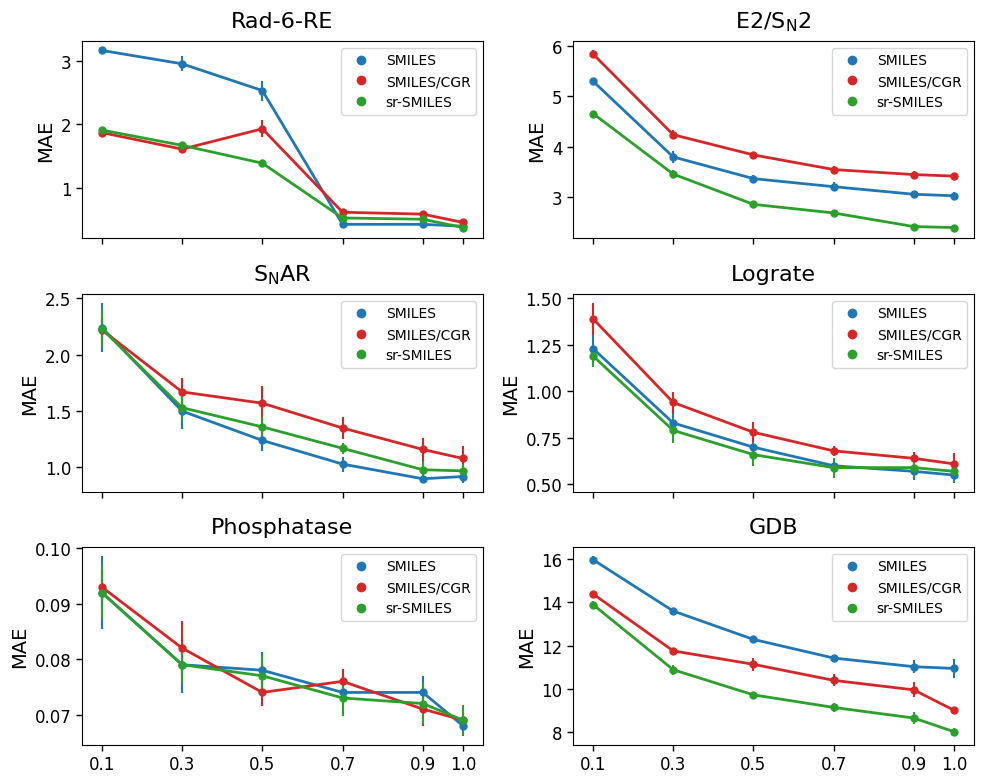

In [101]:
dataset_size_exp(plot_dir)


### Stereochemistry experiment

In [102]:
def save_sn2_toy_experiment_plot(plot_dir: Path):
    model2values = {
        "Chemprop-CGR": {
            "acc": 0.5,
            "acc_std": 0.0
        },
        "Chemprop-diff": {
            "acc": 0.5,
            "acc_std": 0.0
        },
        "RXNFP": {
            "acc": 0.5,
            "acc_std": 0.0
        },
        "SMILES": {
            "acc": 0.5823,
            "acc_std": 0.0028
        },
        "SMILES/CGR": {
            "acc": 0.5,
              "acc_std": 0.0
        },
        "sr-SMILES": {
            "acc": 0.9945,
            "acc_std": 0.0039
        },
        "ReactSeq": {
            "acc": 1.0,
            "acc_std": 0.0
        },
    }
    models = list(model2values.keys())
    acc_means = [model2values[m]["acc"] for m in models]
    acc_stds = [model2values[m]["acc_std"] for m in models]
    colors = ["#1f77b4"] * 3 + ["#d62728"] * 4

    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.linewidth": 0.8,
        "axes.spines.top": True,
        "axes.spines.right": True,
    })

    fig, ax = plt.subplots(figsize=(6, 5))
    x = np.arange(len(models))

    bars = ax.bar(
        x,
        acc_means,
        yerr=acc_stds,
        capsize=3,
        color=colors,
        linewidth=0,
    )
    ax.axhline(
        y=0.5,
        color="#404040",
        linestyle=(0, (4, 3)),
        linewidth=1.0,
        label="Random baseline"
    )
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        err = acc_stds[i]
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + err + 0.03,
            f"{acc_means[i]:.2f}",
            ha="center",
            va="bottom",
            fontsize=11,
            color="black",
        )

    ax.legend(
        loc="upper left",
        frameon=False,
        fontsize=10,
        bbox_to_anchor=(0., 0.9)
    )
    
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_title(r"Synthetic S$_\mathrm{N}$2 Experiment", fontsize=14, pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(False)

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)
        
    ax.set_ylim(0, max(np.array(acc_means) + np.array(acc_stds)) *1.1)
    plt.tight_layout()

    save_path =plot_dir / "sn2_toy_exp.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    fig.show()


[0.5    0.5    0.5    0.5851 0.5    0.9984 1.    ]


/var/folders/m8/8j0c5mbs20q5dx1pnzcq3xjh0000gn/T/ipykernel_60898/3788357868.py:100: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


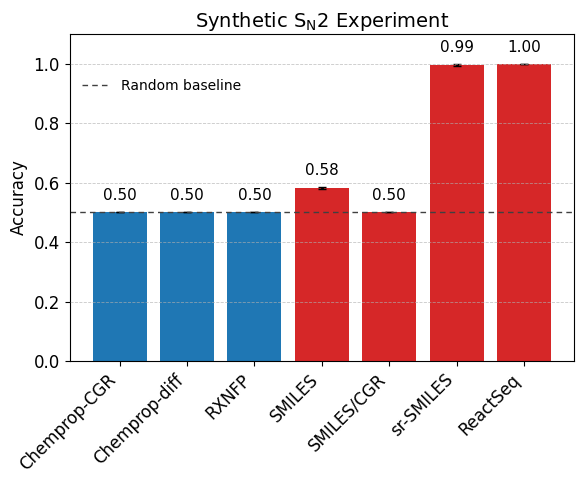

In [103]:
save_sn2_toy_experiment_plot(plot_dir)


# SI plots

### GDB without carbenes

In [104]:
def save_gdb_without_carbenes_subset_plot(plot_dir: Path):
    """
    Grouped bar chart: GDB MAE for SMILES, SMILES/CGR, sr-SMILES
    trained on the full dataset vs. a subset without carbenes.
    Each model gets two bars (full | no-carbene subset), grouped by model.
    """
    data = {
        "SMILES": {
            "full":      {"mae": 10.95, "mae_std": 0.43},
            "subset":      {"mae": 10.63, "mae_std": 0.31},
        },
        "SMILES/CGR": {
            "full":      {"mae": 9.02, "mae_std": 0.09},
            "subset":      {"mae": 9.43, "mae_std": 0.76},
        },
        "sr-SMILES": {
            "full":      {"mae": 8.03, "mae_std": 0.18},
            "subset":      {"mae": 8.59, "mae_std": 0.67},
        },
    }

    models = list(data.keys())
    n_models = len(models)
    conditions = ["full", "subset"]
    bar_width = 0.35
    x = np.arange(n_models)

    model_colors = {
        "SMILES":    "#1f77b4",
        "SMILES/CGR": "#d62728",
        "sr-SMILES": "#2ca02c",
    }

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    offsets = [-bar_width / 2, bar_width / 2]
    hatch_styles = [None, "\\\\\\\\"]
    condition_labels = ["Full dataset", "Subset (no carbenes)"]

    for ci, (cond, offset, hatch, clabel) in enumerate(
        zip(conditions, offsets, hatch_styles, condition_labels)
    ):
        maes = [data[m][cond]["mae"] for m in models]
        stds = [data[m][cond]["mae_std"] / math.sqrt(10) for m in models]
        colors = [model_colors[m] for m in models]

        bars = ax.bar(
            x + offset,
            maes,
            width=bar_width,
            yerr=stds,
            capsize=3,
            color=colors,
            hatch=hatch,
            edgecolor="black",
            linewidth=0.6,
            label=clabel,
            alpha=0.9,
        )

        space = 0.03 * max(maes) if max(maes) > 0 else 0.3
        for bar, mae, std in zip(bars, maes, stds):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                mae + std + space,
                f"{mae:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="black",
            )

    ax.set_ylabel("MAE (kcal/mol)", fontsize=11)
    ax.set_title("Performance on GDB with vs. without carbenes")
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylim(0, None)

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor="grey", edgecolor="white", alpha=0.6, label="Full dataset"),
        Patch(facecolor="grey", edgecolor="white", hatch="\\\\\\\\", alpha=0.6, label="Subset (no carbenes)"),
    ]
    ax.legend(handles=legend_handles, fontsize=9, loc="upper right")

    plt.tight_layout()

    save_path = plot_dir / "gdb_without_carbenes__filtered.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {save_path}")
    plt.show()
    plt.close(fig)


Saved plot to: figures/gdb_without_carbenes__filtered.png


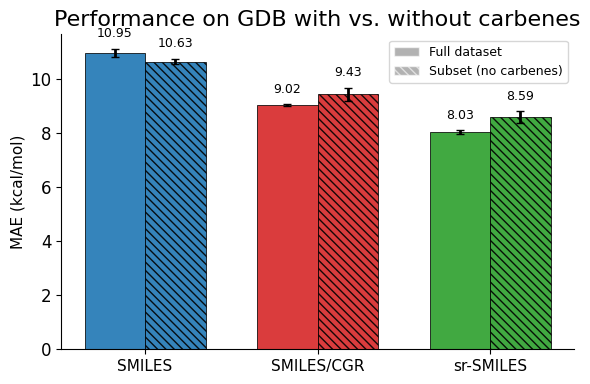

In [105]:
save_gdb_without_carbenes_subset_plot(plot_dir)


### GDB without stereo

In [106]:
def save_gdb_without_stereo_subset_plot(plot_dir: Path):
    """
    Grouped bar chart: GDB MAE for SMILES, SMILES/CGR, sr-SMILES
    trained on the full dataset vs. a subset without stereochemistry.
    Each model gets two bars (full | no-stereo subset), grouped by model.
    """
    # --- Data (fill in values) ---
    data = {
        "SMILES": {
            "full":   {"mae": 10.95, "mae_std": 0.43},
            "subset": {"mae": 11.15, "mae_std": 0.52},
        },
        "SMILES/CGR": {
            "full":   {"mae": 9.02, "mae_std": 0.09},
            "subset": {"mae": 9.18, "mae_std": 0.67},
        },
        "sr-SMILES": {
            "full":   {"mae": 8.03, "mae_std": 0.18},
            "subset": {"mae": 8.32, "mae_std": 0.42},
        },
    }

    models = list(data.keys())
    n_models = len(models)
    conditions = ["full", "subset"]
    bar_width = 0.35
    x = np.arange(n_models)

    model_colors = {
        "SMILES":    "#1f77b4",
        "SMILES/CGR": "#d62728",
        "sr-SMILES": "#2ca02c",
    }

    fig, ax = plt.subplots(figsize=(6, 4))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    offsets = [-bar_width / 2, bar_width / 2]
    hatch_styles = [None, "////"]
    condition_labels = ["Full dataset", "Subset (no stereo)"]

    for ci, (cond, offset, hatch, clabel) in enumerate(
        zip(conditions, offsets, hatch_styles, condition_labels)
    ):
        maes = [data[m][cond]["mae"] for m in models]
        stds = [data[m][cond]["mae_std"] / math.sqrt(10) for m in models]
        colors = [model_colors[m] for m in models]

        bars = ax.bar(
            x + offset,
            maes,
            width=bar_width,
            yerr=stds,
            capsize=3,
            color=colors,
            hatch=hatch,
            edgecolor="black",
            linewidth=0.6,
            label=clabel,
            alpha=0.9,
        )

        space = 0.03 * max(maes) if max(maes) > 0 else 0.3
        for bar, mae, std in zip(bars, maes, stds):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                mae + std + space,
                f"{mae:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="black",
            )

    ax.set_ylabel("MAE (kcal/mol)", fontsize=11)
    ax.set_title("Performance on GDB with vs. without stereochemistry")
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylim(0, None)

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor="grey", edgecolor="white", alpha=0.6, label="Full dataset"),
        Patch(facecolor="grey", edgecolor="white", hatch="////", alpha=0.6, label="Subset (no stereo)"),
    ]
    ax.legend(handles=legend_handles, fontsize=9, loc="upper right")

    plt.tight_layout()

    save_path = plot_dir / "gdb_without_stereo__filtered.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {save_path}")
    plt.show()
    plt.close(fig)


Saved plot to: figures/gdb_without_stereo__filtered.png


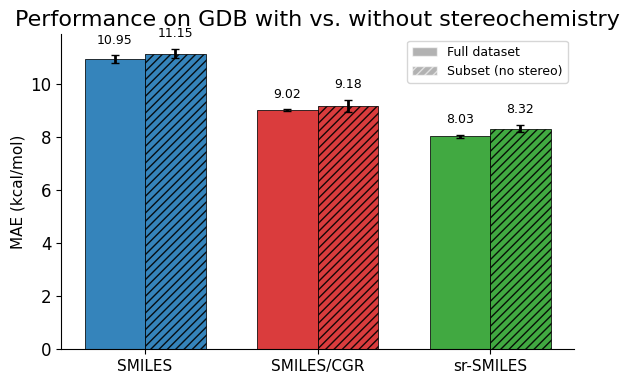

In [107]:
save_gdb_without_stereo_subset_plot(plot_dir)


### E2SN2 SMILES reordering: shuffled vs. canonical

In [108]:
def save_smiles_order_plot(plot_dir: Path):
    """
    Grouped bar chart: E2/SN2 MAE for SMILES, SMILES/CGR, sr-SMILES
    under three SMILES ordering conditions: original, shuffled, canonicalized.
    Colors represent models, hatching represents the dataset variant.
    """
    data = {
        "SMILES": {
            "original":      {"mae": 3.03, "mae_std": 0.07},
            "shuffled":      {"mae": 4.27, "mae_std": 0.24},
            "canonicalized": {"mae": 3.02, "mae_std": 0.19},
        },
        "SMILES/CGR": {
            "original":      {"mae": 3.42, "mae_std": 0.05},
            "shuffled":      {"mae": 3.42, "mae_std": 0.12},
            "canonicalized": {"mae": 3.42, "mae_std": 0.06},
        },
        "sr-SMILES": {
            "original":      {"mae": 2.40, "mae_std": 0.03},
            "shuffled":      {"mae": 3.69, "mae_std": 0.23},
            "canonicalized": {"mae": 2.83, "mae_std": 0.17},
        },
    }

    models = list(data.keys())
    n_models = len(models)
    conditions = ["original", "shuffled", "canonicalized"]
    bar_width = 0.25
    x = np.arange(n_models)

    model_colors = {
        "SMILES":     "#1f77b4",
        "SMILES/CGR": "#d62728",
        "sr-SMILES":  "#2ca02c",
    }

    condition_hatches = {
        "original":      "",
        "shuffled":      "//",
        "canonicalized": "xx",
    }

    condition_labels = {
        "original":      "Original",
        "shuffled":      "Shuffled",
        "canonicalized": "Canonicalized",
    }

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    offsets = [-bar_width, 0, bar_width]

    condition_legend_added = {c: False for c in conditions}

    for i, model in enumerate(models):
        for cond, offset in zip(conditions, offsets):
            mae = data[model][cond]["mae"]
            std = data[model][cond]["mae_std"] / math.sqrt(10)

            label = (
                condition_labels[cond]
                if not condition_legend_added[cond]
                else None
            )
            condition_legend_added[cond] = True

            bar = ax.bar(
                x[i] + offset,
                mae,
                width=bar_width,
                yerr=std,
                capsize=3,
                color=model_colors[model],
                edgecolor="black",
                linewidth=0.8,
                hatch=condition_hatches[cond],
                label=label,
                alpha=0.9,
            )

            space = 0.03 * mae if mae > 0 else 0.3
            ax.text(
                bar[0].get_x() + bar[0].get_width() / 2,
                mae + std + space,
                f"{mae:.2f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="black",
            )

    ax.set_ylabel("MAE (kcal/mol)", fontsize=11)
    ax.set_title("Effect of SMILES ordering on model performance")
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.set_ylim(0, None)

    ax.legend(fontsize=9, loc="upper right")

    plt.tight_layout()

    save_path = plot_dir / "e2sn2_shuffled_and_canonicalized.png"
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {save_path}")
    plt.show()
    plt.close(fig)


Saved plot to: figures/e2sn2_shuffled_and_canonicalized.png


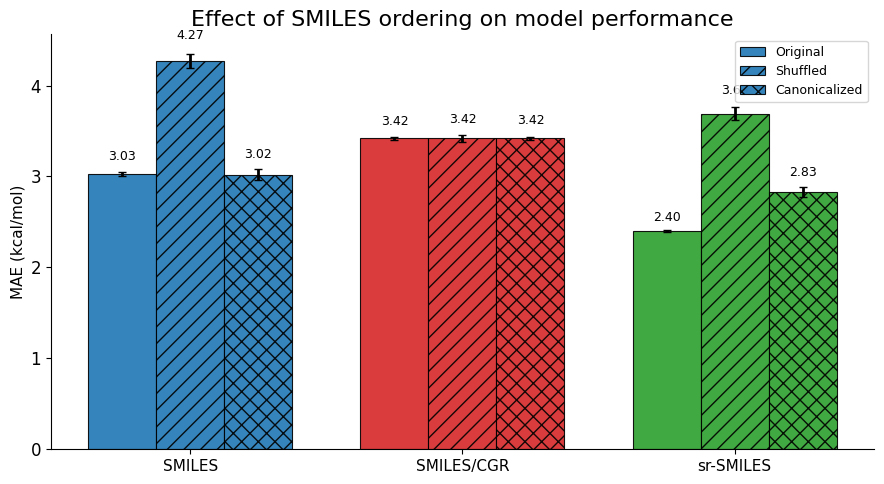

In [109]:
save_smiles_order_plot(plot_dir)
